# Lab 2 - Preparação dos Dados
## Importação e carregamento

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df_treino = pd.read_csv('../material/lab2_cmc13_dados_treinamento.csv')
df_teste = pd.read_csv('../material/lab2_cmc13_dados_teste.csv')

## Diagnóstico




In [36]:
print(f'Treino: {df_treino.shape[0]} linhas, {df_treino.shape[1]} colunas')
print(f'Teste:  {df_teste.shape[0]} linhas, {df_teste.shape[1]} colunas')
df_treino.head()

Treino: 440833 linhas, 12 colunas
Teste:  64374 linhas, 12 colunas


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [37]:
# Linhas completamente vazias (todos os valores NaN)
linhas_vazias = df_treino[df_treino.isnull().all(axis=1)]
print(f"Linhas completamente vazias: {len(linhas_vazias)}")
print(f"Índices: {linhas_vazias.index.tolist()}")
linhas_vazias
# Remover linhas completamente vazias
df_treino = df_treino.dropna(how='all').reset_index(drop=True)
print(f"Treino após remoção: {df_treino.shape[0]} linhas")

Linhas completamente vazias: 1
Índices: [199295]
Treino após remoção: 440832 linhas


In [38]:
df_treino.info()
print("------------")
df_teste.info()

<class 'pandas.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 48.5 MB
------------
<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ---

## Ajustes Iniciais

Transformações aplicadas antes da análise exploratória para que os gráficos reflitam as features que serão efetivamente usadas nos modelos:

1. **Remover `CustomerID`** — identificador, sem valor preditivo
2. **Converter float → int** (treino) — artefato da linha NaN removida
3. **Label Encoding em `Gender`** — binária (Male=0, Female=1)
4. **Ordinal Encoding em `Contract Length`** — ordem natural de duração (Monthly=1, Quarterly=3, Annual=12)
5. **One-Hot Encoding em `Subscription Type`** — sem ordem natural entre categorias (drop_first=True)

In [39]:
# 1. Remover CustomerID
df_treino = df_treino.drop(columns=['CustomerID'])
df_teste = df_teste.drop(columns=['CustomerID'])

# 2. Converter float → int (treino)
cols_float = df_treino.select_dtypes(include=[float]).columns
df_treino[cols_float] = df_treino[cols_float].astype(int)

# 3. Label Encoding — Gender (Male=0, Female=1)
df_treino['Gender'] = df_treino['Gender'].map({'Male': 0, 'Female': 1})
df_teste['Gender'] = df_teste['Gender'].map({'Male': 0, 'Female': 1})

# 4. Ordinal Encoding — Contract Length (Monthly=1, Quarterly=3, Annual=12)
df_treino['Contract Length'] = df_treino['Contract Length'].map({'Monthly': 1, 'Quarterly': 3, 'Annual': 12})
df_teste['Contract Length'] = df_teste['Contract Length'].map({'Monthly': 1, 'Quarterly': 3, 'Annual': 12})

# 5. One-Hot Encoding — Subscription Type (drop_first=True)
df_treino = pd.get_dummies(df_treino, columns=['Subscription Type'], drop_first=True, dtype=int)
df_teste = pd.get_dummies(df_teste, columns=['Subscription Type'], drop_first=True, dtype=int)

# Dicionário de labels para legibilidade nos gráficos
labels = {
    'Gender': {0: 'Male', 1: 'Female'},
    'Contract Length': {1: 'Monthly', 3: 'Quarterly', 12: 'Annual'}
}

print(f'Treino: {df_treino.shape} | Teste: {df_teste.shape}')
df_treino.head()

Treino: (440832, 12) | Teste: (64374, 12)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Contract Length,Total Spend,Last Interaction,Churn,Subscription Type_Premium,Subscription Type_Standard
0,30,1,39,14,5,18,12,932,17,1,0,1
1,65,1,49,1,10,8,1,557,6,1,0,0
2,55,1,14,4,6,18,3,185,3,1,0,0
3,58,0,38,21,7,7,1,396,29,1,0,1
4,23,0,32,20,5,8,1,617,20,1,0,0


## Análise Exploratória

In [40]:
# Comparação Treino vs Teste — todas as features (agora numéricas)
print("=" * 80)
print("COMPARAÇÃO TREINO vs TESTE - LADO A LADO")
print("=" * 80)

for col in df_treino.columns:
    print(f"\n{'─' * 80}")
    label_extra = ''
    if col in labels:
        label_extra = f"  ({', '.join(f'{k}={v}' for k, v in labels[col].items())})"
    print(f"  {col}{label_extra}")
    print(f"{'─' * 80}")
    
    stats = pd.DataFrame({
        'Treino': [
            df_treino[col].count(),
            df_treino[col].isnull().sum(),
            df_treino[col].nunique(),
            df_treino[col].mean(),
            df_treino[col].std(),
            df_treino[col].min(),
            df_treino[col].quantile(0.25),
            df_treino[col].median(),
            df_treino[col].quantile(0.75),
            df_treino[col].max(),
            df_treino[col].skew(),
            df_treino[col].kurtosis()
        ],
        'Teste': [
            df_teste[col].count(),
            df_teste[col].isnull().sum(),
            df_teste[col].nunique(),
            df_teste[col].mean(),
            df_teste[col].std(),
            df_teste[col].min(),
            df_teste[col].quantile(0.25),
            df_teste[col].median(),
            df_teste[col].quantile(0.75),
            df_teste[col].max(),
            df_teste[col].skew(),
            df_teste[col].kurtosis()
        ]
    }, index=['count', 'missing', 'únicos', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis'])
    print(stats.to_string())

COMPARAÇÃO TREINO vs TESTE - LADO A LADO

────────────────────────────────────────────────────────────────────────────────
  Age
────────────────────────────────────────────────────────────────────────────────
                 Treino         Teste
count     440832.000000  64374.000000
missing        0.000000      0.000000
únicos        48.000000     48.000000
mean          39.373153     41.970982
std           12.442369     13.924911
min           18.000000     18.000000
25%           29.000000     30.000000
50%           39.000000     42.000000
75%           48.000000     54.000000
max           65.000000     65.000000
skew           0.162016     -0.040894
kurtosis      -0.864853     -1.215321

────────────────────────────────────────────────────────────────────────────────
  Gender  (0=Male, 1=Female)
────────────────────────────────────────────────────────────────────────────────
                 Treino         Teste
count     440832.000000  64374.000000
missing        0.000000     

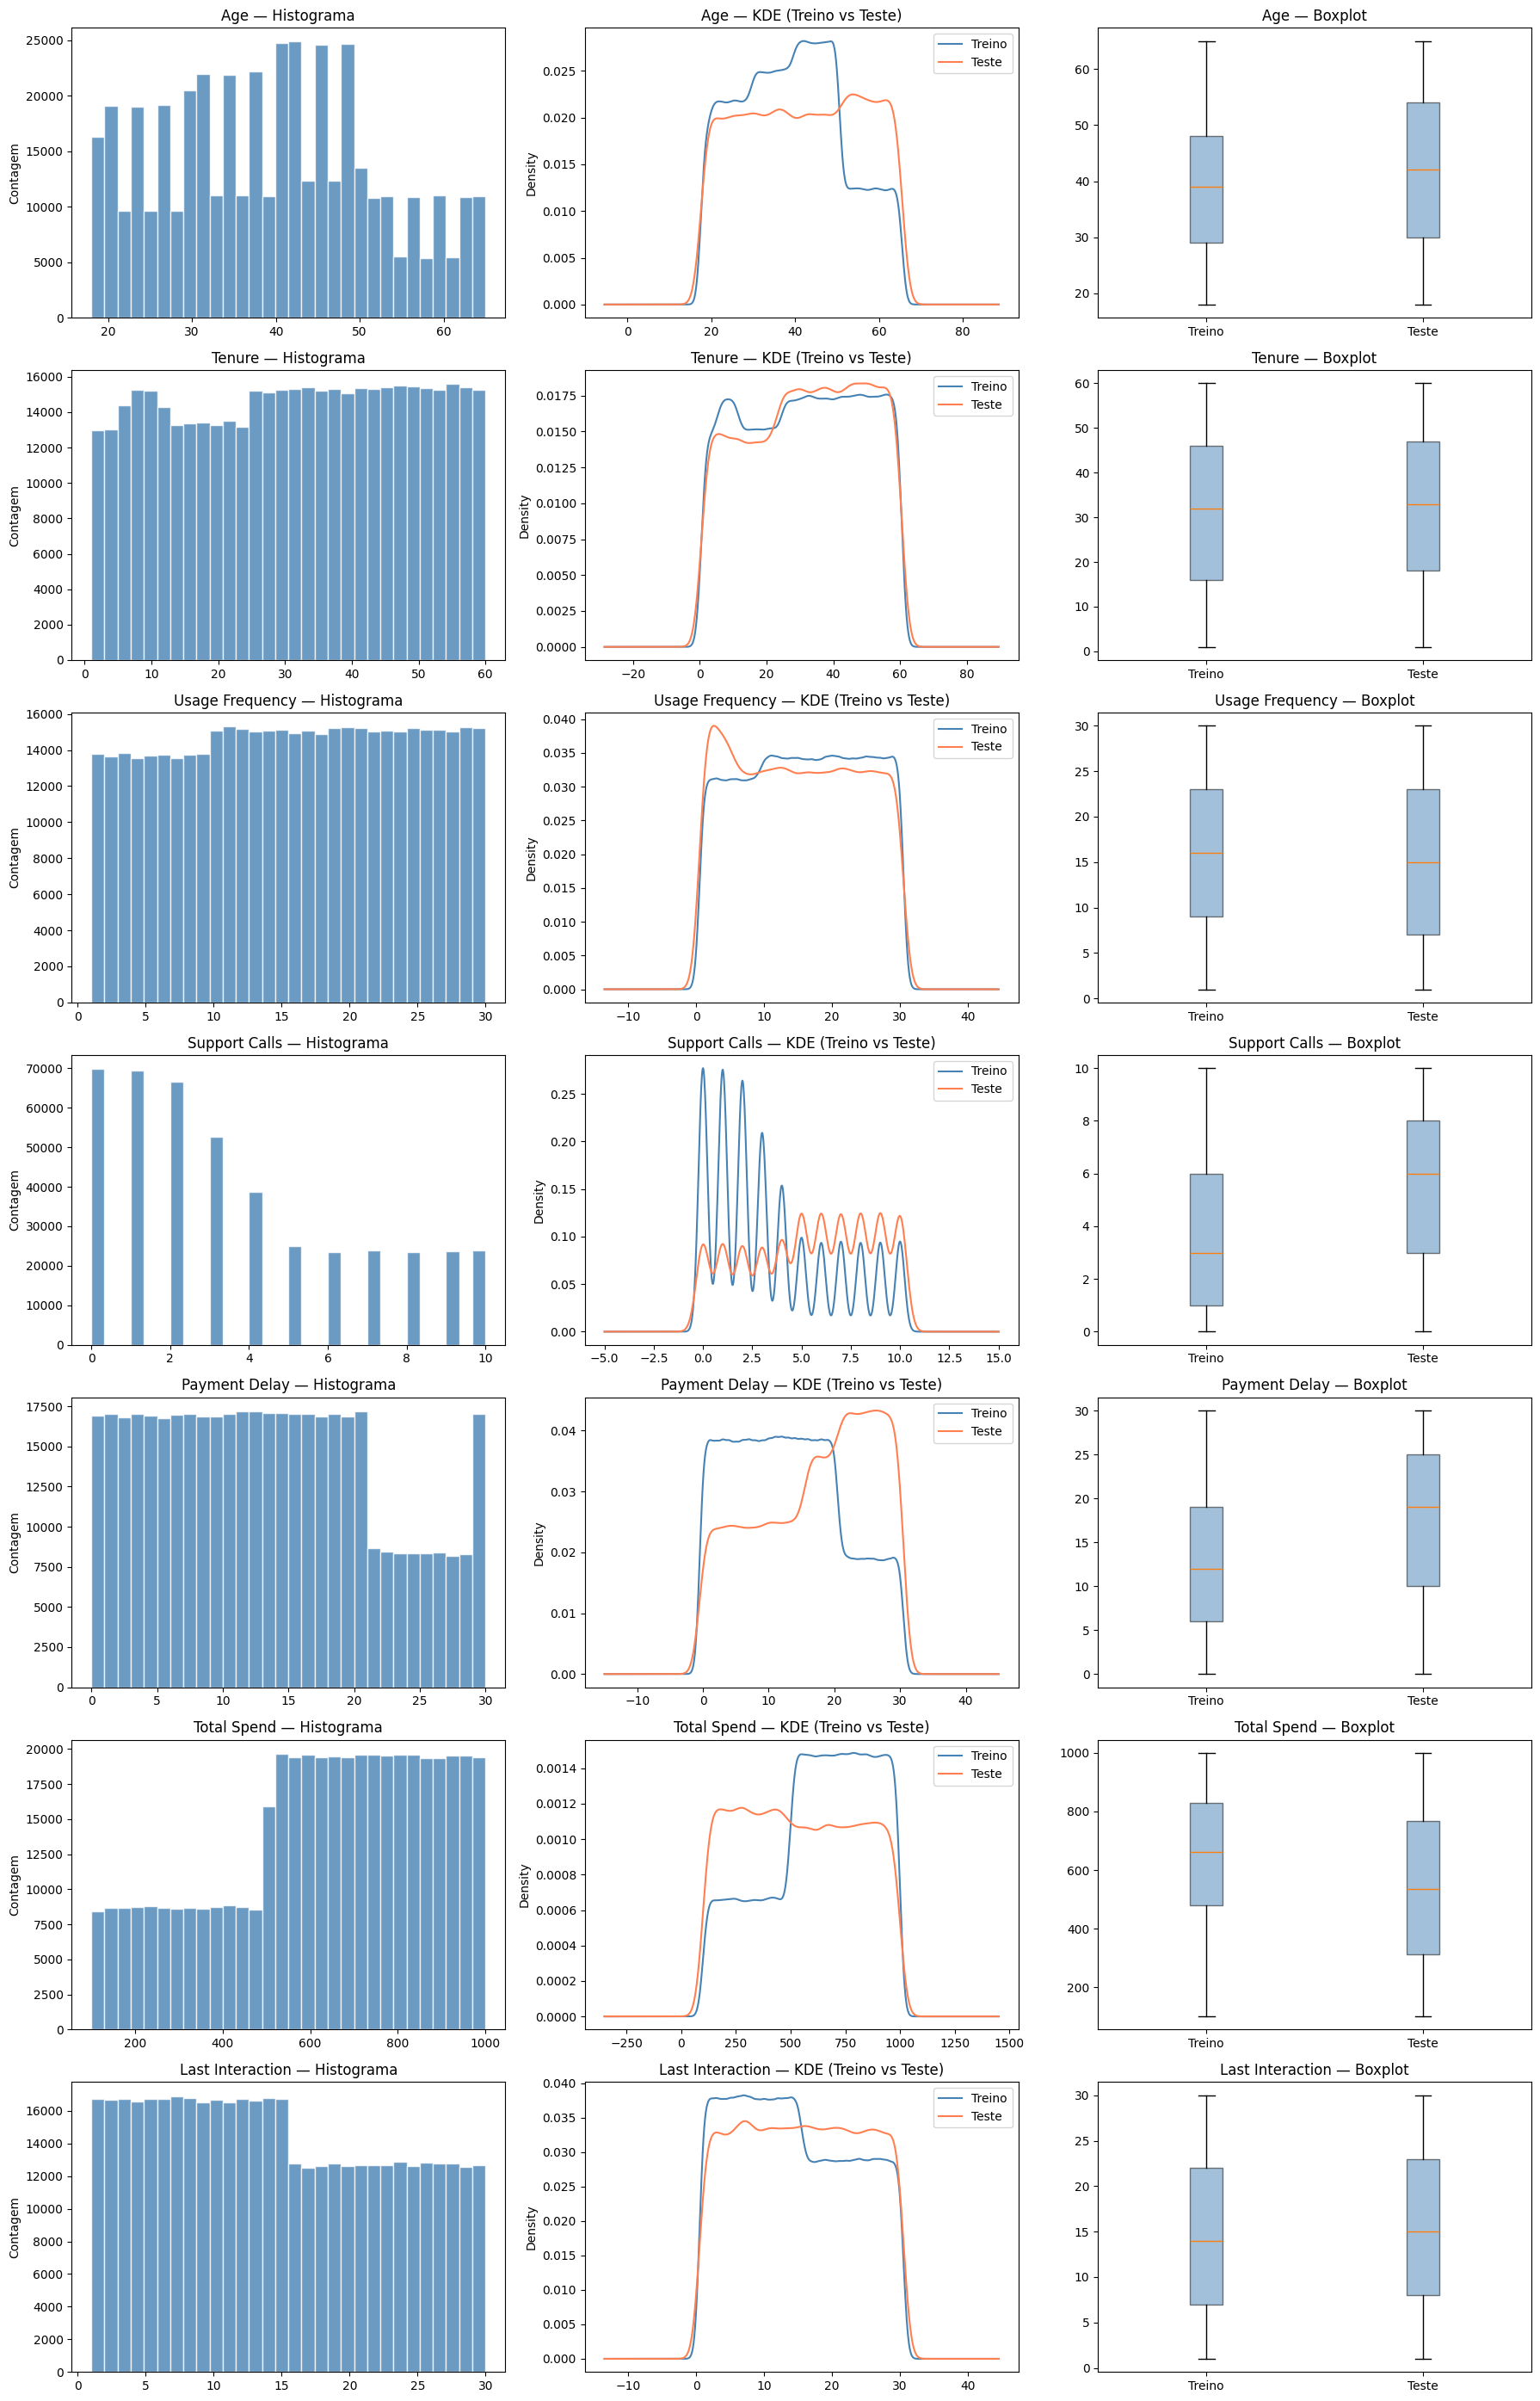

In [41]:
# Features contínuas: Histograma + KDE + Boxplot
cols_continuas = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                  'Payment Delay', 'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(len(cols_continuas), 3, figsize=(18, 4 * len(cols_continuas)))

for i, col in enumerate(cols_continuas):
    # Histograma
    axes[i, 0].hist(df_treino[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{col} — Histograma')
    axes[i, 0].set_ylabel('Contagem')
    
    # KDE
    df_treino[col].plot.kde(ax=axes[i, 1], color='steelblue', label='Treino')
    df_teste[col].plot.kde(ax=axes[i, 1], color='coral', label='Teste')
    axes[i, 1].set_title(f'{col} — KDE (Treino vs Teste)')
    axes[i, 1].legend()
    
    # Boxplot
    axes[i, 2].boxplot(
        [df_treino[col], df_teste[col]],
        tick_labels=['Treino', 'Teste'], vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.5)
    )
    axes[i, 2].set_title(f'{col} — Boxplot')

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_histogramas_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

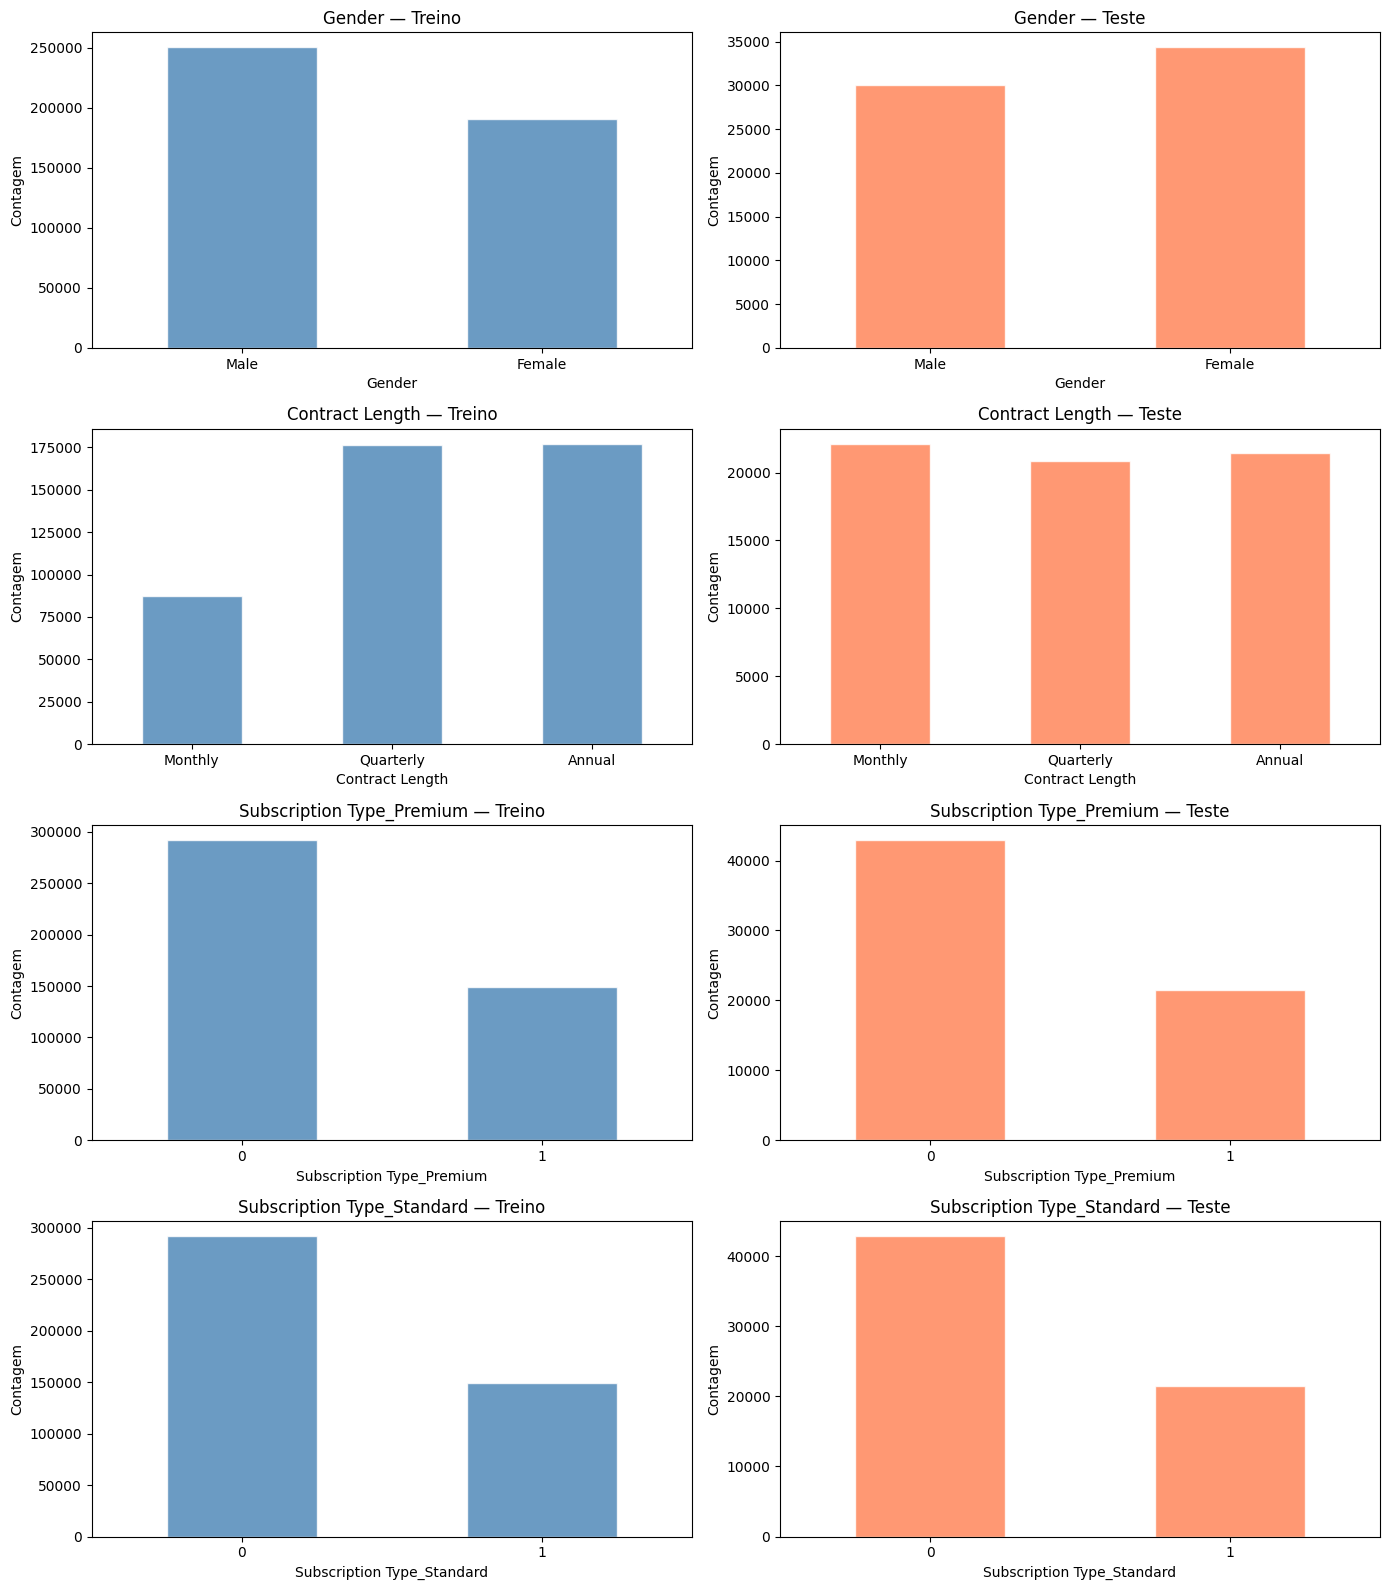

In [42]:
# Features codificadas (ex-categóricas): Countplot com labels legíveis
cols_encoded = ['Gender', 'Contract Length', 'Subscription Type_Premium', 'Subscription Type_Standard']

fig, axes = plt.subplots(len(cols_encoded), 2, figsize=(14, 4 * len(cols_encoded)))

for i, col in enumerate(cols_encoded):
    for j, (df, nome, cor) in enumerate([(df_treino, 'Treino', 'steelblue'), (df_teste, 'Teste', 'coral')]):
        contagem = df[col].value_counts().sort_index()
        contagem.plot.bar(ax=axes[i, j], color=cor, edgecolor='white', alpha=0.8)
        axes[i, j].set_title(f'{col} — {nome}')
        axes[i, j].set_ylabel('Contagem')
        
        # Substituir rótulos numéricos pelos nomes originais
        if col in labels:
            tick_labels = [labels[col].get(int(v.get_text()), v.get_text()) for v in axes[i, j].get_xticklabels()]
            axes[i, j].set_xticklabels(tick_labels, rotation=0)
        else:
            axes[i, j].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_countplot_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

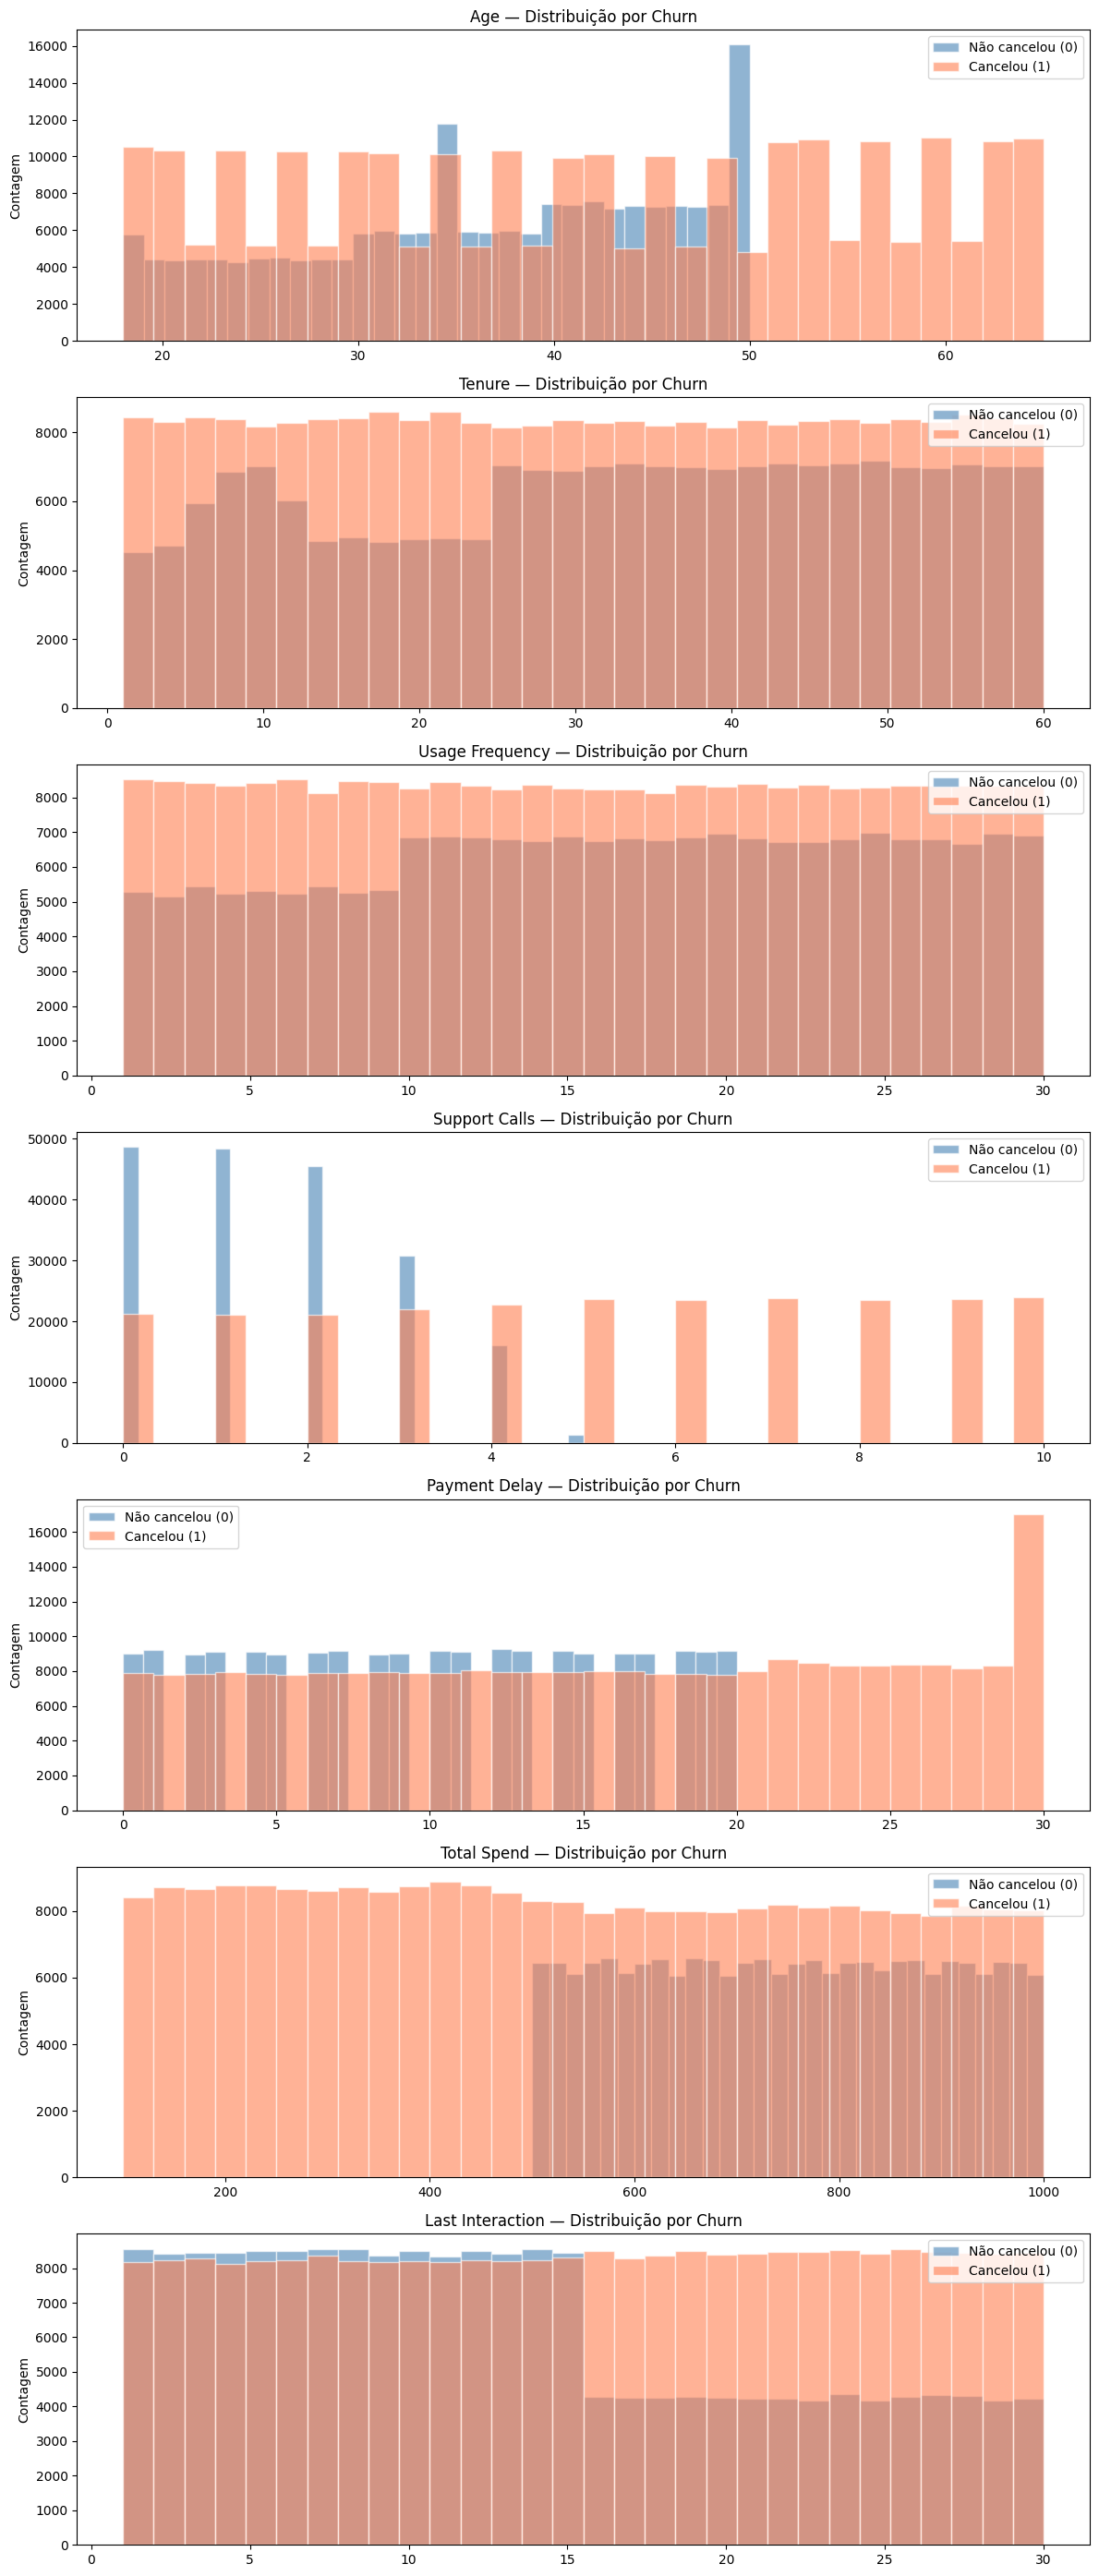

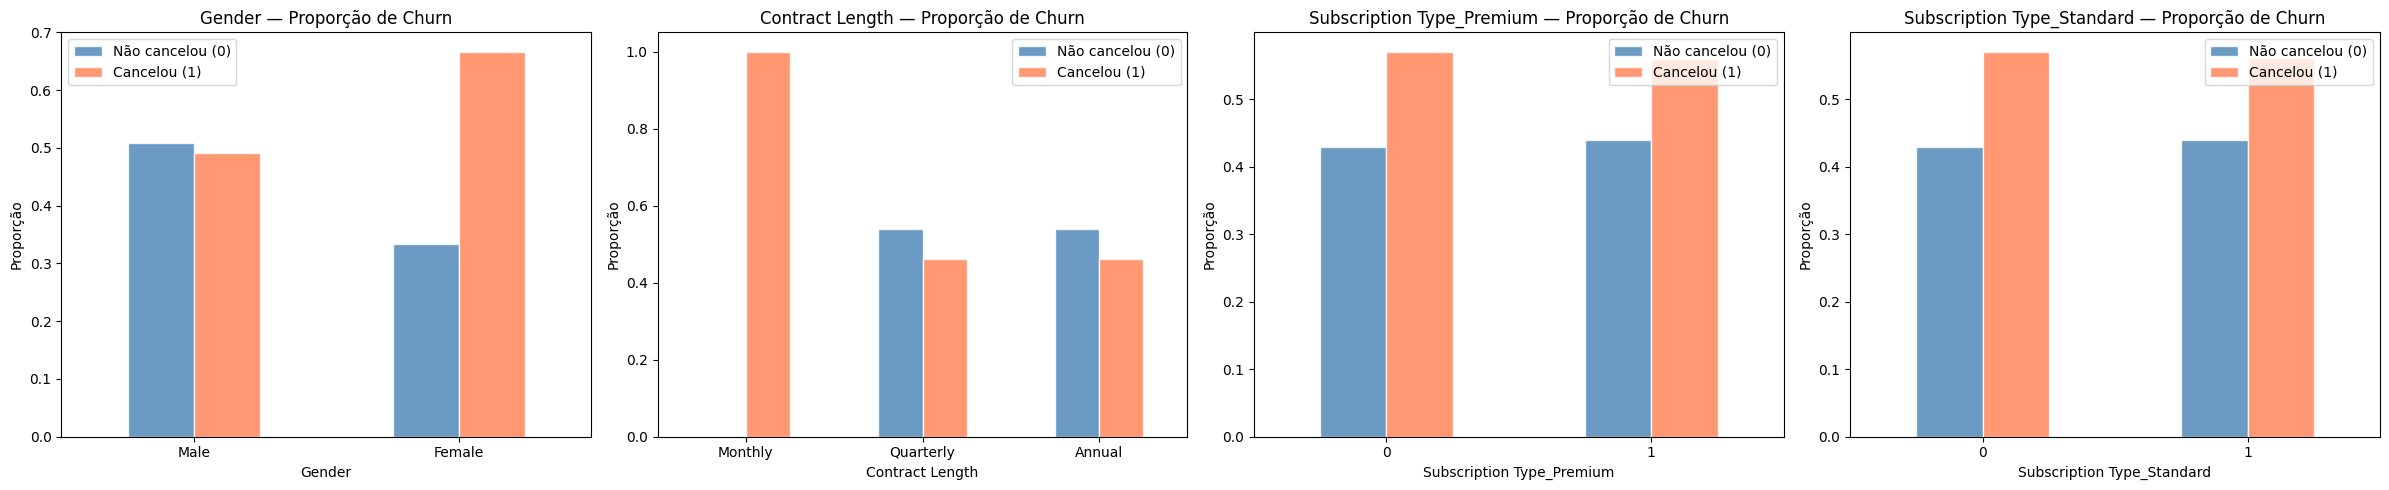

In [43]:
# Distribuição por Churn — features contínuas
fig, axes = plt.subplots(len(cols_continuas), 1, figsize=(12, 4 * len(cols_continuas)))

for i, col in enumerate(cols_continuas):
    df_treino[df_treino['Churn'] == 0][col].plot.hist(
        ax=axes[i], bins=30, alpha=0.6, color='steelblue', label='Não cancelou (0)', edgecolor='white'
    )
    df_treino[df_treino['Churn'] == 1][col].plot.hist(
        ax=axes[i], bins=30, alpha=0.6, color='coral', label='Cancelou (1)', edgecolor='white'
    )
    axes[i].set_title(f'{col} — Distribuição por Churn')
    axes[i].set_ylabel('Contagem')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_distribuicao_por_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribuição por Churn — features codificadas
fig, axes = plt.subplots(1, len(cols_encoded), figsize=(6 * len(cols_encoded), 5))

for i, col in enumerate(cols_encoded):
    ct = pd.crosstab(df_treino[col], df_treino['Churn'], normalize='index')
    ct.plot.bar(ax=axes[i], color=['steelblue', 'coral'], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} — Proporção de Churn')
    axes[i].set_ylabel('Proporção')
    axes[i].legend(['Não cancelou (0)', 'Cancelou (1)'])
    
    if col in labels:
        tick_labels = [labels[col].get(int(v.get_text()), v.get_text()) for v in axes[i].get_xticklabels()]
        axes[i].set_xticklabels(tick_labels, rotation=0)
    else:
        axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_churn_por_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

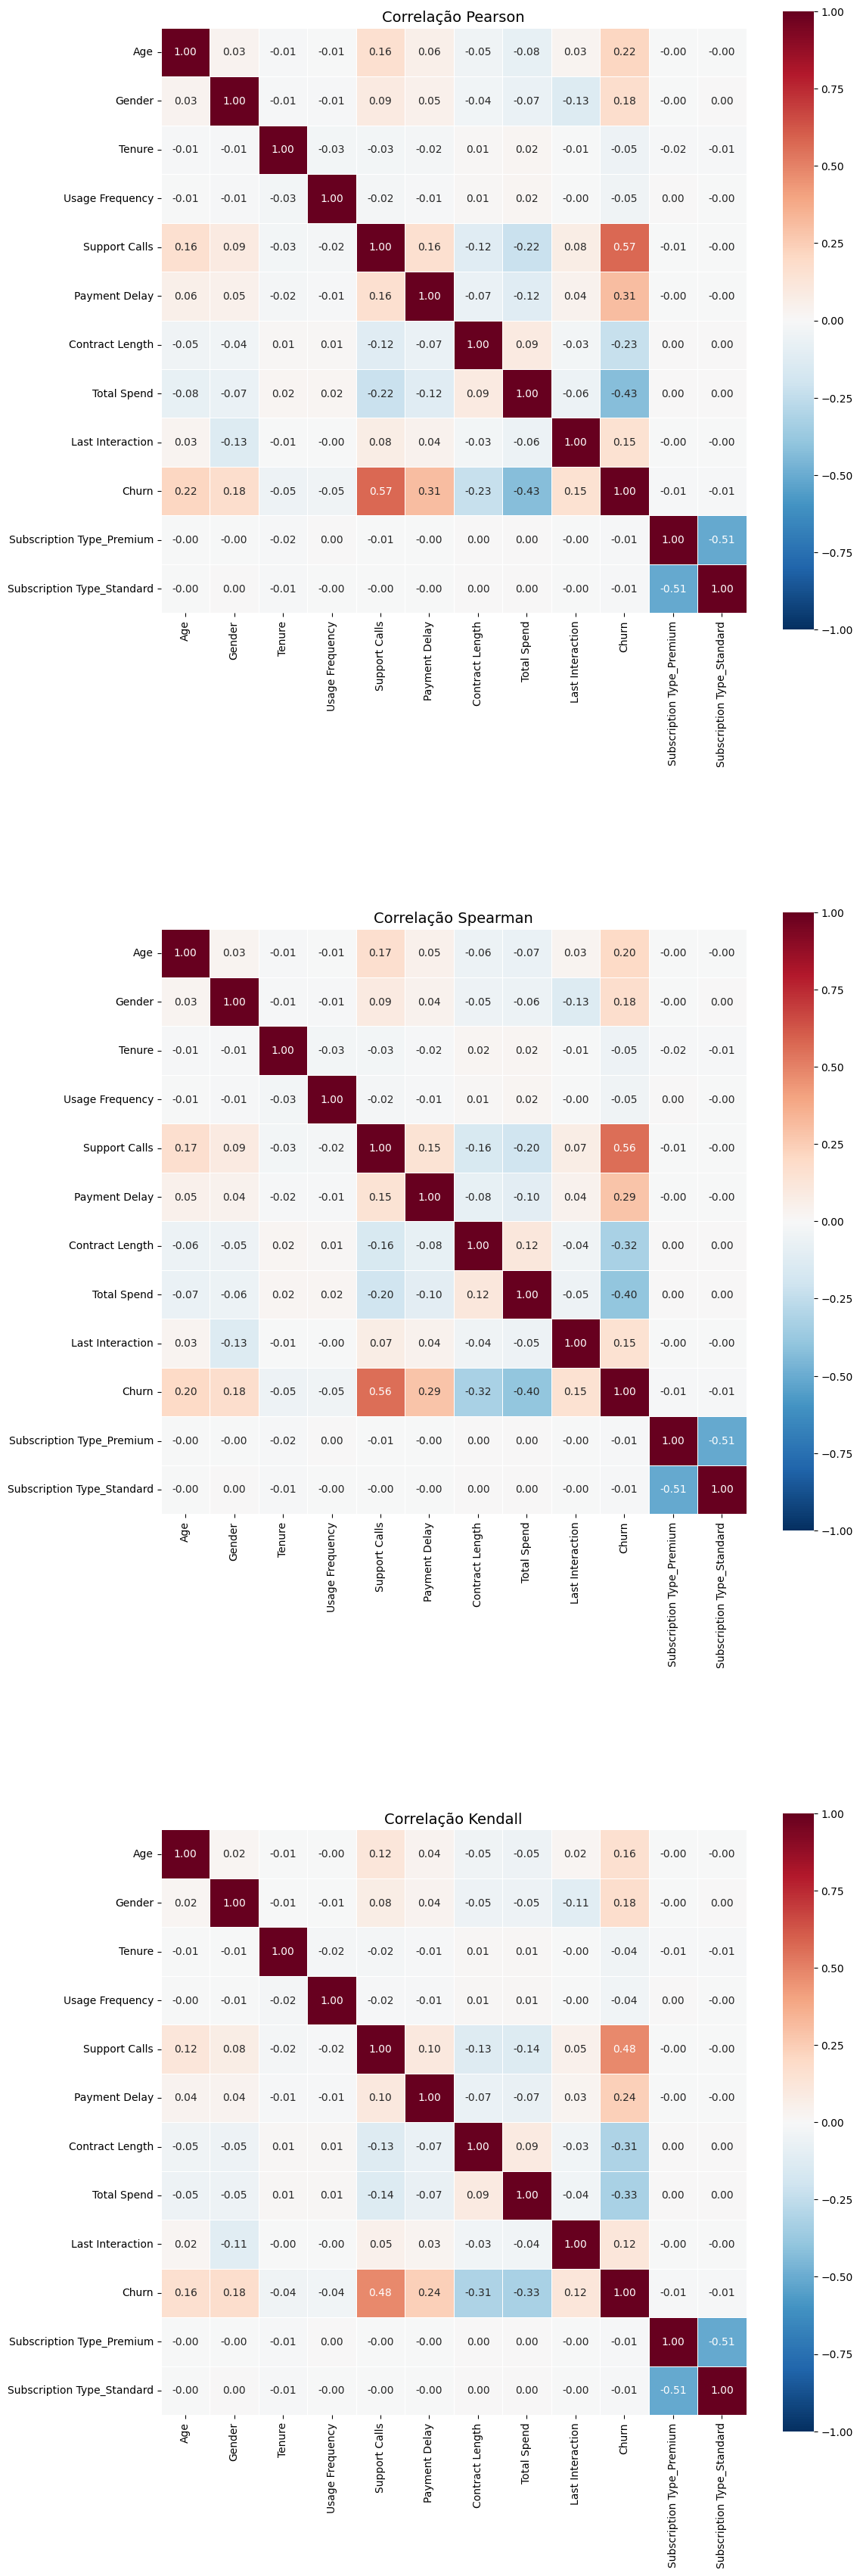

In [46]:
# Correlação — todas as features (agora numéricas)
metodos = ['pearson', 'spearman', 'kendall']

fig, axes = plt.subplots(3, 1, figsize=(12, 36))

for i, metodo in enumerate(metodos):
    matriz = df_treino.corr(method=metodo)
    sns.heatmap(
        matriz, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
        vmin=-1, vmax=1, ax=axes[i], square=True,
        linewidths=0.5, cbar_kws={'shrink': 0.8}
    )
    axes[i].set_title(f'Correlação {metodo.capitalize()}', fontsize=14)

plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_correlacao_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

=== Correlação Point-Biserial com Churn ===

                           correlação    p-value
Support Calls                  0.5743   0.00e+00
Total Spend                   -0.4287   0.00e+00
Payment Delay                  0.3121   0.00e+00
Contract Length               -0.2341   0.00e+00
Age                            0.2184   0.00e+00
Gender                         0.1754   0.00e+00
Last Interaction               0.1496   0.00e+00
Tenure                        -0.0519  9.58e-261
Usage Frequency               -0.0461  5.69e-206
Subscription Type_Premium     -0.0111   1.96e-13
Subscription Type_Standard    -0.0092   8.28e-10


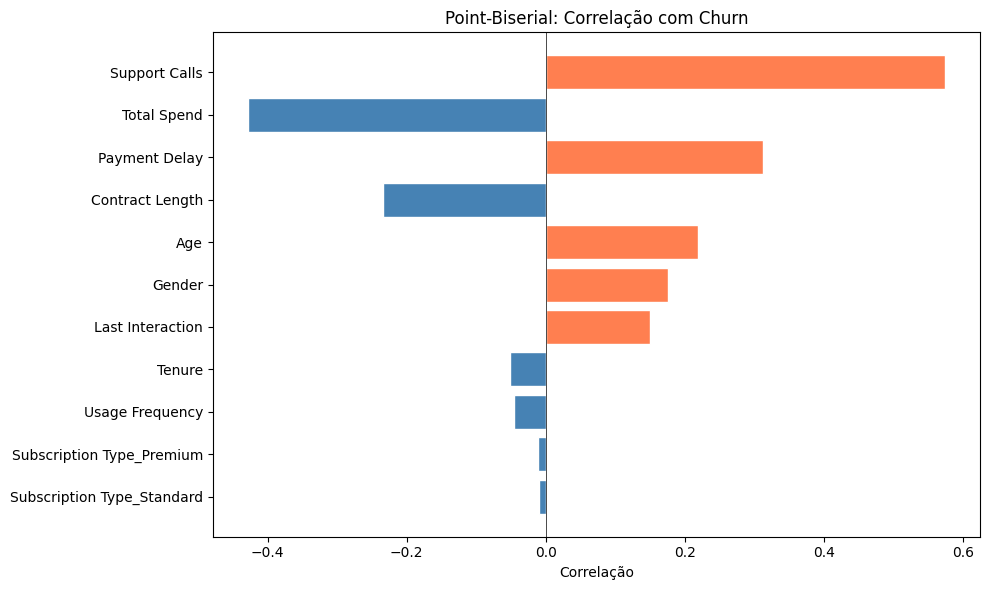

In [45]:
# Point-Biserial: correlação de cada feature com Churn
from scipy.stats import pointbiserialr

print("=== Correlação Point-Biserial com Churn ===\n")

cols_features = [c for c in df_treino.columns if c != 'Churn']

resultados = {}
for col in cols_features:
    corr, pvalue = pointbiserialr(df_treino['Churn'], df_treino[col])
    resultados[col] = {'correlação': corr, 'p-value': pvalue}

pb = pd.DataFrame(resultados).T.sort_values('correlação', key=abs, ascending=False)
pb['correlação'] = pb['correlação'].map('{:.4f}'.format)
pb['p-value'] = pb['p-value'].map('{:.2e}'.format)
print(pb.to_string())

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
vals = pd.DataFrame(resultados).T.sort_values('correlação', key=abs, ascending=True)
colors = ['coral' if v > 0 else 'steelblue' for v in vals['correlação']]
ax.barh(vals.index, vals['correlação'], color=colors, edgecolor='white')
ax.set_title('Point-Biserial: Correlação com Churn')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlação')
plt.tight_layout()
plt.savefig('../relatorio/imagens/1_prep_point_biserial.png', dpi=150, bbox_inches='tight')
plt.show()

## Exportação dos Dados Processados

Salva os dados já limpos e codificados em formato Parquet para uso direto nos notebooks de modelagem.
Os dados são separados em features (X) e alvo (y). **Nenhuma normalização é aplicada aqui** — cada modelo aplicará a sua própria conforme necessário (ex: StandardScaler para KNN/SVM/MLP).

In [ ]:
import os
from datetime import datetime

# Separar features e alvo
target = 'Churn'
X_train = df_treino.drop(columns=[target])
y_train = df_treino[[target]]
X_test = df_teste.drop(columns=[target])
y_test = df_teste[[target]]

# Criar diretório de saída
output_dir = './dados_processados'
os.makedirs(output_dir, exist_ok=True)

# Exportar em Parquet
X_train.to_parquet(f'{output_dir}/X_train.parquet', index=False)
y_train.to_parquet(f'{output_dir}/y_train.parquet', index=False)
X_test.to_parquet(f'{output_dir}/X_test.parquet', index=False)
y_test.to_parquet(f'{output_dir}/y_test.parquet', index=False)

print(f'Dados exportados em {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'  X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape}  |  y_test:  {y_test.shape}')
print(f'  Features: {list(X_train.columns)}')